In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import expon
import re

In [2]:
# excel
data_path = './WT_unique_pairs_relabeled.xlsx'
data = pd.read_excel(data_path)
# remove if 'Abonormal' or 'Blocked' or 'Brownian' or 'short' or 'test' in relabeling_notes
data = data[~data['relabeling_notes'].str.contains('Abnormal|Blocked|Brownian|short|test', na=False)]
data.columns

Index(['Well_index', 'Folder_index', 'Bug_capusle_pair_index', 'Capsule_index',
       'Video_index', 'pixel_inner_D_of_capsule', 'um_body_length',
       'inner_diameter/body_length', 'Capsule_size', 'Forward_I', 'Forward_II',
       'Impeded_Forward', 'Backward', 'Impeded_Backward', 'Stop',
       'Stuck_on_hole', 'Linear', 'relabeling_notes'],
      dtype='object')

In [3]:
# split based on Capsule_size
print(data['Capsule_size'].unique())
data_large = data[data['Capsule_size'] == 'Large']
data_small = data[data['Capsule_size'] == 'Small']
data_middle = data[data['Capsule_size'] == 'Middle']
print('number of large:', len(data_large))
print('number of small:', len(data_small))
print('number of middle:', len(data_middle))


['Large' 'Small' 'Middle']
number of large: 113
number of small: 57
number of middle: 2


In [4]:
# get inner_diameter/body_length
dimension_ratio_large = data_large['inner_diameter/body_length']
dimension_ratio_small = data_small['inner_diameter/body_length']
# convert to numpy array
dimension_ratio_large = np.array(dimension_ratio_large)
dimension_ratio_small = np.array(dimension_ratio_small)
# convert to pd dataframe
dimension_ratio_large = pd.DataFrame(dimension_ratio_large, columns=['dimension_ratio'])
dimension_ratio_small = pd.DataFrame(dimension_ratio_small, columns=['dimension_ratio'])

In [5]:
# Updated colors (colorblind-friendly)
color_Forward_I = '#88CEE6'       # Blue (Forward I)
color_Forward_II = '#80C1C4'      # Blue-Green (Forward II)
color_Backward = '#E89DA0'        # Red (Backward)
color_Impeded_Forward = '#984ea3' # Purple (Impeded Forward)
color_Impeded_Backward = '#ff7f00' # Orange (Impeded Backward)

data_current = data_large.copy()
# prepare data
data_current_processed = pd.DataFrame(columns=['unique_index', 'Forward_I', 'Forward_II', 'Backward', 'Impeded_Forward', 'Impeded_Backward', 'Forward_all', 'Backward_all', 'Forward_all_raw', 'Backward_all_raw', 'capsule_size', 'bug_size'])
y_line = 0
for unique_index in data_current['Bug_capusle_pair_index'].unique():
    y_line += 1
    # get the data for this index
    data_current_index = data_current[data_current['Bug_capusle_pair_index'] == unique_index]
    # get the time range for each motion mode
    range_Forward_I_raw = '' if pd.isna(data_current_index['Forward_I'].values[0]) else data_current_index['Forward_I'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Forward_I_raw)
    time_ranges_Forward_I = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Forward_II_raw = '' if pd.isna(data_current_index['Forward_II'].values[0]) else data_current_index['Forward_II'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Forward_II_raw)
    time_ranges_Forward_II = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Backward_raw = '' if pd.isna(data_current_index['Backward'].values[0]) else data_current_index['Backward'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Backward_raw)
    time_ranges_Backward = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Impeded_Forward_raw = '' if pd.isna(data_current_index['Impeded_Forward'].values[0]) else data_current_index['Impeded_Forward'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Impeded_Forward_raw)
    time_ranges_Impeded_Forward = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Impeded_Backward_raw = '' if pd.isna(data_current_index['Impeded_Backward'].values[0]) else data_current_index['Impeded_Backward'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Impeded_Backward_raw)
    time_ranges_Impeded_Backward = [tuple(map(int, r.split('-'))) for r in ranges]

    # # plot horizontal line colored by the mode
    # for time_range in time_ranges_Forward_I:
    #     plt.plot(time_range, [y_line, y_line], color=color_Forward_I, linewidth=5)
    # for time_range in time_ranges_Forward_II:
    #     plt.plot(time_range, [y_line, y_line], color=color_Forward_II, linewidth=5)
    # for time_range in time_ranges_Backward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Backward, linewidth=5)
    # for time_range in time_ranges_Impeded_Forward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Impeded_Forward, linewidth=5)
    # for time_range in time_ranges_Impeded_Backward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Impeded_Backward, linewidth=5)

    # find the time ranges at the ends
    time_ranges_all = time_ranges_Forward_I + time_ranges_Forward_II + time_ranges_Backward + time_ranges_Impeded_Forward + time_ranges_Impeded_Backward
    time_ranges_all.sort()
    # if len(time_ranges_all) > 1:
    #     end_ranges = [time_ranges_all[0], time_ranges_all[-1]]
    # elif len(time_ranges_all) == 1:
    #     end_ranges = [time_ranges_all[0]]
    # else:
    #     end_ranges = []
    end_ranges = []
    
    # remove end ranges from separate time ranges
    time_ranges_Forward_I_middle = [time_range for time_range in time_ranges_Forward_I if time_range not in end_ranges]
    time_ranges_Forward_II_middle = [time_range for time_range in time_ranges_Forward_II if time_range not in end_ranges]
    time_ranges_Backward_middle = [time_range for time_range in time_ranges_Backward if time_range not in end_ranges]
    time_ranges_Impeded_Forward_middle = [time_range for time_range in time_ranges_Impeded_Forward if time_range not in end_ranges]
    time_ranges_Impeded_Backward_middle = [time_range for time_range in time_ranges_Impeded_Backward if time_range not in end_ranges]

    motion_mode = []
    # if not empty, add in motion mode
    if len(time_ranges_Forward_I_middle) > 0:
        motion_mode.append('F_I')
    if len(time_ranges_Forward_II_middle) > 0:
        motion_mode.append('F_II')
    if len(time_ranges_Backward_middle) > 0:
        motion_mode.append('B')
    if len(time_ranges_Impeded_Forward_middle) > 0:
        motion_mode.append('i_F')
    if len(time_ranges_Impeded_Backward_middle) > 0:
        motion_mode.append('i_B')

    # convert time ranges to length of time ranges (excluding end ranges)
    duration_Forward_I = [end - start +1 for start, end in time_ranges_Forward_I_middle]
    duration_Forward_II = [end - start +1 for start, end in time_ranges_Forward_II_middle]
    duration_Backward = [end - start +1 for start, end in time_ranges_Backward_middle]
    duration_Impeded_Forward = [end - start +1 for start, end in time_ranges_Impeded_Forward_middle]
    duration_Impeded_Backward = [end - start +1 for start, end in time_ranges_Impeded_Backward_middle]

    # connect forward time range, and backward time range if they are adjacent (including end ranges)
    time_ranges_Forward_all = time_ranges_Forward_I + time_ranges_Forward_II + time_ranges_Impeded_Forward
    time_ranges_Backward_all = time_ranges_Backward + time_ranges_Impeded_Backward
    time_ranges_Forward_all.sort()
    if len(time_ranges_Forward_all) > 0:
        merged_Forward = [time_ranges_Forward_all[0]]
        for current in time_ranges_Forward_all[1:]:
            prev_start, prev_end = merged_Forward[-1]
            curr_start, curr_end = current
            if curr_start == prev_end + 1:
                merged_Forward[-1] = (prev_start, curr_end)
            else:
                merged_Forward.append(current)
    else:
        merged_Forward = []
    time_ranges_Backward_all.sort()
    if len(time_ranges_Backward_all) > 0:
        merged_Backward = [time_ranges_Backward_all[0]]
        for current in time_ranges_Backward_all[1:]:
            prev_start, prev_end = merged_Backward[-1]
            curr_start, curr_end = current
            if curr_start == prev_end + 1:
                merged_Backward[-1] = (prev_start, curr_end)
            else:
                merged_Backward.append(current)
    else:
        merged_Backward = []

    # # plot connected time ranges
    # for time_range in merged_Forward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Forward_I, linewidth=5)
    # for time_range in merged_Backward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Backward, linewidth=5)

    # find time ranges at the ends
    time_ranges_all = merged_Forward + merged_Backward
    time_ranges_all.sort()
    if len(time_ranges_all) > 1:
        end_ranges = [time_ranges_all[0], time_ranges_all[-1]]
    elif len(time_ranges_all) == 1:
        end_ranges = [time_ranges_all[0]]
    else:
        end_ranges = []
    # # remove end ranges from merged time ranges
    # merged_Forward_middle = [time_range for time_range in merged_Forward if time_range not in end_ranges]
    # merged_Backward_middle = [time_range for time_range in merged_Backward if time_range not in end_ranges]
    # # match number of time ranges
    # if len(merged_Forward_middle) > len(merged_Backward_middle):
    #     # remove the shortest time range from merged_Forward_middle
    #     merged_Forward_middle = sorted(merged_Forward_middle, key=lambda x: x[1] - x[0])[:-1]
    # elif len(merged_Forward_middle) < len(merged_Backward_middle):
    #     # remove the shortest time range from merged_Backward_middle
    #     merged_Backward_middle = sorted(merged_Backward_middle, key=lambda x: x[1] - x[0])[:-1]
    merged_Forward_middle = merged_Forward
    merged_Backward_middle = merged_Backward

    # convert time ranges to length of time ranges (excluding end ranges)
    duration_Forward_all = [end - start +1 for start, end in merged_Forward_middle]
    duration_Backward_all = [end - start +1 for start, end in merged_Backward_middle]

    # save
    data_current_processed = pd.concat([data_current_processed, pd.DataFrame({
        'unique_index': [unique_index],
        'Forward_I': [duration_Forward_I],
        'Forward_II': [duration_Forward_II],
        'Backward': [duration_Backward],
        'Impeded_Forward': [duration_Impeded_Forward],
        'Impeded_Backward': [duration_Impeded_Backward],
        'Forward_all': [duration_Forward_all],
        'Backward_all': [duration_Backward_all],
        'Forward_all_raw': [merged_Forward],
        'Backward_all_raw': [merged_Backward],
        'capsule_size': [data_current_index['pixel_inner_D_of_capsule'].values[0]*0.11] , # 0.11 um/pixel
        'bug_size': [data_current_index['um_body_length'].values[0]],
        'motion_mode': [motion_mode]
    })], ignore_index=True)

    

large_processed = data_current_processed.copy()

In [6]:
data_current = data_small.copy()
# prepare data
data_current_processed = pd.DataFrame(columns=['unique_index', 'Forward_I', 'Forward_II', 'Backward', 'Impeded_Forward', 'Impeded_Backward', 'Forward_all', 'Backward_all', 'Forward_all_raw', 'Backward_all_raw', 'capsule_size', 'bug_size', 'motion_mode'])
y_line = 0
for unique_index in data_current['Bug_capusle_pair_index'].unique():
    y_line += 1
    # get the data for this index
    data_current_index = data_current[data_current['Bug_capusle_pair_index'] == unique_index]
    # get the time range for each motion mode
    range_Forward_I_raw = '' if pd.isna(data_current_index['Forward_I'].values[0]) else data_current_index['Forward_I'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Forward_I_raw)
    time_ranges_Forward_I = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Forward_II_raw = '' if pd.isna(data_current_index['Forward_II'].values[0]) else data_current_index['Forward_II'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Forward_II_raw)
    time_ranges_Forward_II = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Backward_raw = '' if pd.isna(data_current_index['Backward'].values[0]) else data_current_index['Backward'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Backward_raw)
    time_ranges_Backward = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Impeded_Forward_raw = '' if pd.isna(data_current_index['Impeded_Forward'].values[0]) else data_current_index['Impeded_Forward'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Impeded_Forward_raw)
    time_ranges_Impeded_Forward = [tuple(map(int, r.split('-'))) for r in ranges]
    range_Impeded_Backward_raw = '' if pd.isna(data_current_index['Impeded_Backward'].values[0]) else data_current_index['Impeded_Backward'].values[0]
    ranges = re.findall(r'\d+\s*-\s*\d+', range_Impeded_Backward_raw)
    time_ranges_Impeded_Backward = [tuple(map(int, r.split('-'))) for r in ranges]

    # # plot horizontal line colored by the mode
    # for time_range in time_ranges_Forward_I:
    #     plt.plot(time_range, [y_line, y_line], color=color_Forward_I, linewidth=5)
    # for time_range in time_ranges_Forward_II:
    #     plt.plot(time_range, [y_line, y_line], color=color_Forward_II, linewidth=5)
    # for time_range in time_ranges_Backward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Backward, linewidth=5)
    # for time_range in time_ranges_Impeded_Forward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Impeded_Forward, linewidth=5)
    # for time_range in time_ranges_Impeded_Backward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Impeded_Backward, linewidth=5)

    # find the time ranges at the ends
    time_ranges_all = time_ranges_Forward_I + time_ranges_Forward_II + time_ranges_Backward + time_ranges_Impeded_Forward + time_ranges_Impeded_Backward
    time_ranges_all.sort()
    # if len(time_ranges_all) > 1:
    #     end_ranges = [time_ranges_all[0], time_ranges_all[-1]]
    # elif len(time_ranges_all) == 1:
    #     end_ranges = [time_ranges_all[0]]
    # else:
    #     end_ranges = []
    end_ranges = []
    
    # remove end ranges from separate time ranges
    time_ranges_Forward_I_middle = [time_range for time_range in time_ranges_Forward_I if time_range not in end_ranges]
    time_ranges_Forward_II_middle = [time_range for time_range in time_ranges_Forward_II if time_range not in end_ranges]
    time_ranges_Backward_middle = [time_range for time_range in time_ranges_Backward if time_range not in end_ranges]
    time_ranges_Impeded_Forward_middle = [time_range for time_range in time_ranges_Impeded_Forward if time_range not in end_ranges]
    time_ranges_Impeded_Backward_middle = [time_range for time_range in time_ranges_Impeded_Backward if time_range not in end_ranges]

    motion_mode = []
    # if not empty, add in motion mode
    if len(time_ranges_Forward_I_middle) > 0:
        motion_mode.append('F_I')
    if len(time_ranges_Forward_II_middle) > 0:
        motion_mode.append('F_II')
    if len(time_ranges_Backward_middle) > 0:
        motion_mode.append('B')
    if len(time_ranges_Impeded_Forward_middle) > 0:
        motion_mode.append('i_F')
    if len(time_ranges_Impeded_Backward_middle) > 0:
        motion_mode.append('i_B')


    # convert time ranges to length of time ranges (excluding end ranges)
    duration_Forward_I = [end - start+1 for start, end in time_ranges_Forward_I_middle]
    duration_Forward_II = [end - start+1 for start, end in time_ranges_Forward_II_middle]
    duration_Backward = [end - start+1 for start, end in time_ranges_Backward_middle]
    duration_Impeded_Forward = [end - start+1 for start, end in time_ranges_Impeded_Forward_middle]
    duration_Impeded_Backward = [end - start+1 for start, end in time_ranges_Impeded_Backward_middle]

    # connect forward time range, and backward time range if they are adjacent (including end ranges)
    time_ranges_Forward_all = time_ranges_Forward_I + time_ranges_Forward_II + time_ranges_Impeded_Forward
    time_ranges_Backward_all = time_ranges_Backward + time_ranges_Impeded_Backward
    time_ranges_Forward_all.sort()
    if len(time_ranges_Forward_all) > 0:
        merged_Forward = [time_ranges_Forward_all[0]]
        for current in time_ranges_Forward_all[1:]:
            prev_start, prev_end = merged_Forward[-1]
            curr_start, curr_end = current
            if curr_start == prev_end + 1:
                merged_Forward[-1] = (prev_start, curr_end)
            else:
                merged_Forward.append(current)
    else:
        merged_Forward = []
    time_ranges_Backward_all.sort()
    if len(time_ranges_Backward_all) > 0:
        merged_Backward = [time_ranges_Backward_all[0]]
        for current in time_ranges_Backward_all[1:]:
            prev_start, prev_end = merged_Backward[-1]
            curr_start, curr_end = current
            if curr_start == prev_end + 1:
                merged_Backward[-1] = (prev_start, curr_end)
            else:
                merged_Backward.append(current)
    else:
        merged_Backward = []

    # # plot connected time ranges
    # for time_range in merged_Forward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Forward_I, linewidth=5)
    # for time_range in merged_Backward:
    #     plt.plot(time_range, [y_line, y_line], color=color_Backward, linewidth=5)

    # find time ranges at the ends
    time_ranges_all = merged_Forward + merged_Backward
    time_ranges_all.sort()
    if len(time_ranges_all) > 1:
        end_ranges = [time_ranges_all[0], time_ranges_all[-1]]
    elif len(time_ranges_all) == 1:
        end_ranges = [time_ranges_all[0]]
    else:
        end_ranges = []
    # # remove end ranges from merged time ranges
    # merged_Forward_middle = [time_range for time_range in merged_Forward if time_range not in end_ranges]
    # merged_Backward_middle = [time_range for time_range in merged_Backward if time_range not in end_ranges]
    # # match number of time ranges
    # if len(merged_Forward_middle) > len(merged_Backward_middle):
    #     # remove the shortest time range from merged_Forward_middle
    #     merged_Forward_middle = sorted(merged_Forward_middle, key=lambda x: x[1] - x[0])[:-1]
    # elif len(merged_Forward_middle) < len(merged_Backward_middle):
    #     # remove the shortest time range from merged_Backward_middle
    #     merged_Backward_middle = sorted(merged_Backward_middle, key=lambda x: x[1] - x[0])[:-1]
    merged_Forward_middle = merged_Forward
    merged_Backward_middle = merged_Backward

    # convert time ranges to length of time ranges (excluding end ranges)
    duration_Forward_all = [end - start+1 for start, end in merged_Forward_middle]
    duration_Backward_all = [end - start+1 for start, end in merged_Backward_middle]

    # save
    data_current_processed = pd.concat([data_current_processed, pd.DataFrame({
        'unique_index': [unique_index],
        'Forward_I': [duration_Forward_I],
        'Forward_II': [duration_Forward_II],
        'Backward': [duration_Backward],
        'Impeded_Forward': [duration_Impeded_Forward],
        'Impeded_Backward': [duration_Impeded_Backward],
        'Forward_all': [duration_Forward_all],
        'Backward_all': [duration_Backward_all],
        'Forward_all_raw': [merged_Forward],
        'Backward_all_raw': [merged_Backward],
        'capsule_size': [data_current_index['pixel_inner_D_of_capsule'].values[0]*0.11] , # 0.11 um/pixel
        'bug_size': [data_current_index['um_body_length'].values[0]],
        'motion_mode': [motion_mode]
    })], ignore_index=True)

    

small_processed = data_current_processed.copy()

In [7]:
# ---mean of the durations---
large_processed['Forward_mean'] = large_processed['Forward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
large_processed['Backward_mean'] = large_processed['Backward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
large_processed['Total_mean'] = large_processed['Forward_mean'] + large_processed['Backward_mean']
# calculate the fraction
large_processed['Backward_fraction'] = large_processed['Backward_mean'] / large_processed['Total_mean']

small_processed['Forward_mean'] = small_processed['Forward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
small_processed['Backward_mean'] = small_processed['Backward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
small_processed['Total_mean'] = small_processed['Forward_mean'] + small_processed['Backward_mean']
small_processed['Backward_fraction'] = small_processed['Backward_mean'] / small_processed['Total_mean']

# ---sum the durations---
large_processed['Forward_sum'] = large_processed['Forward_all'].apply(lambda x: sum(x) if isinstance(x, list) else 0)
large_processed['Backward_sum'] = large_processed['Backward_all'].apply(lambda x: sum(x) if isinstance(x, list) else 0)
large_processed['Total_sum'] = large_processed['Forward_sum'] + large_processed['Backward_sum']
# calculate the fraction
large_processed['Backward_fraction_based_on_sum'] = large_processed['Backward_sum'] / large_processed['Total_sum']
# sort by Forward_fraction
large_processed = large_processed.sort_values(by='Backward_fraction', ascending=True)

small_processed['Forward_sum'] = small_processed['Forward_all'].apply(lambda x: sum(x) if isinstance(x, list) else 0)
small_processed['Backward_sum'] = small_processed['Backward_all'].apply(lambda x: sum(x) if isinstance(x, list) else 0)
small_processed['Total_sum'] = small_processed['Forward_sum'] + small_processed['Backward_sum']
small_processed['Backward_fraction_based_on_sum'] = small_processed['Backward_sum'] / small_processed['Total_sum']
small_processed = small_processed.sort_values(by='Backward_fraction', ascending=True)



# print mean, std, median, and count
print('large capsule size')
print('mean:', large_processed['Backward_fraction'].dropna().mean())
print('std:', large_processed['Backward_fraction'].dropna().std())
print('median:', large_processed['Backward_fraction'].dropna().median())
print('count:', large_processed['Backward_fraction'].dropna().count())
print('small capsule size')
print('mean:', small_processed['Backward_fraction'].dropna().mean())
print('std:', small_processed['Backward_fraction'].dropna().std())
print('median:', small_processed['Backward_fraction'].dropna().median())
print('count:', small_processed['Backward_fraction'].dropna().count())

# save to csv
# large_processed.to_csv('./large_processed.csv', index=False)
# small_processed.to_csv('./small_processed.csv', index=False)


large capsule size
mean: 0.3484515759190954
std: 0.1586256328323284
median: 0.33663521594684387
count: 108
small capsule size
mean: 0.2551092296954002
std: 0.11071032119123898
median: 0.23234200743494424
count: 57


c:\ProgramData\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [8]:
data_plot = large_processed.copy()
# timepoints_check = [1, 401, 801, 1201]
# randomly generate num_points points between 1 and 1200
import random
num_points = 100
timepoints_check = random.sample(range(1, 1201), num_points)
timepoints_F = []
timepoints_B = []
for i in range(len(data_plot)):
    # plot horizontal line colored by the mode
    for time_range in data_plot['Forward_all_raw'][i]:
        # if contains timepoints_check, count
        if any(tp in range(time_range[0], time_range[1]+1) for tp in timepoints_check):
            timepoints_F.append(data_plot['unique_index'][i])
    for time_range in data_plot['Backward_all_raw'][i]:
        # if contains timepoints_check, count
        if any(tp in range(time_range[0], time_range[1]+1) for tp in timepoints_check):
            timepoints_B.append(data_plot['unique_index'][i])
# length of timepoints_F and timepoints_B
print(len(timepoints_F), len(timepoints_B))
print(len(timepoints_F)/(len(timepoints_F)+len(timepoints_B)))

378 327
0.5361702127659574


In [9]:
# compare duration of Forward and Backward
durations_forward_all_large = large_processed['Forward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
durations_backward_all_large = large_processed['Backward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
durations_forward_all_small = small_processed['Forward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)
durations_backward_all_small = small_processed['Backward_all'].apply(lambda x: np.mean(x) if isinstance(x, list) else 0)

c:\ProgramData\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


large: N= 108 mean= 0.3484515759190954 std= 0.1578895470376617 median= 0.33663521594684387
small: N= 57 mean= 0.2551092296954002 std= 0.10973488084509488 median= 0.23234200743494424


C:\Users\SSLabPowerfulJunior\AppData\Local\Temp\ipykernel_35196\456242212.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,


Forward_duration - Welch’s t-test
  FI vs. FII: t = 4.410, p = 1.957e-05, ***
Forward entry:
Median: 0.34
Mean+-std: 0.35+-0.16
Backward entry:
Median: 0.23
Mean+-std: 0.26+-0.11


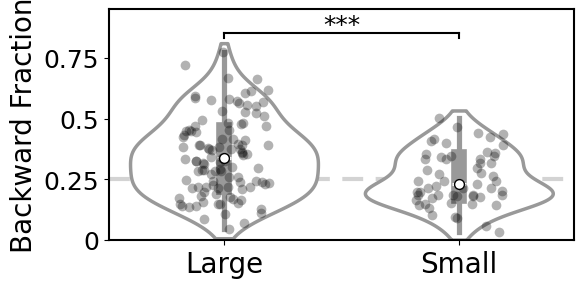

In [10]:
from scipy import stats

# Define line thickness
thickness_axis = 1.5
thickness_box = 1.5
thickness_violin = 2.5
thickness_mean = 1.5
FPS = 47.22

key_parameter = 'Forward_duration'

# Define box plot colors
# colors = ['#333333', 'dimgray', 'darkgray']
# colors = ['#333333', 'darkgray']
colors = ['dimgray', 'darkgray']

data_current = large_processed.copy()
# prepare data
data_current['Forward_mean'] = data_current['Forward_all'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
data_current['Backward_mean'] = data_current['Backward_all'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
data_current['Fraction_backward'] = data_current['Backward_mean'] / (data_current['Forward_mean'] + data_current['Backward_mean'])
data_1 = data_current['Fraction_backward'].dropna()

data_current = small_processed.copy()
# prepare data
data_current['Forward_mean'] = data_current['Forward_all'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
data_current['Backward_mean'] = data_current['Backward_all'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
data_current['Fraction_backward'] = data_current['Backward_mean'] / (data_current['Forward_mean'] + data_current['Backward_mean'])
data_2 = data_current['Fraction_backward'].dropna()

# Get the data for each group
# data_1 = df_WT[key_parameter].dropna()
# data_2 = df_FO[key_parameter].dropna()
# data_1 = durations_forward_all_large.dropna()
# data_2 = durations_forward_all_small.dropna()

# convert to seconds
# data_1 = data_1 / FPS
# data_2 = data_2 / FPS
# calculate mean and std before log
data_1_mean = np.mean(data_1)
data_1_std = np.std(data_1)
data_2_mean = np.mean(data_2)
data_2_std = np.std(data_2)

print('large: N=', len(data_1), 'mean=', data_1_mean, 'std=', data_1_std, 'median=', np.median(data_1))
print('small: N=', len(data_2), 'mean=', data_2_mean, 'std=', data_2_std, 'median=', np.median(data_2))

# Convert to numeric arrays
data_1 = np.array(data_1, dtype=np.float64)
data_2 = np.array(data_2, dtype=np.float64)



# # Remove outliers (> k*std, < k*std)
# outlier_k = 3
# data_1 = data_1[(data_1 > np.mean(data_1) - outlier_k * np.std(data_1)) & 
#                    (data_1 < np.mean(data_1) + outlier_k * np.std(data_1))]

# data_2 = data_2[(data_2 > np.mean(data_2) - outlier_k * np.std(data_2)) & 
#                      (data_2 < np.mean(data_2) + outlier_k * np.std(data_2))]

# print('before - after removing outliers:')
# print(f'FI: {len_FI} - {len(data_1)}')
# print(f'FII: {len_FII} - {len(data_2)}')

# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [data_1, data_2]])

# Perform statistical test (Welch’s t-test if normal, Mann-Whitney U otherwise)
if normality:
    stat, p_value = stats.ttest_ind(data_1, data_2, equal_var=False)  # Welch's t-test
    stat_symbol = "t"
    test_name = "Welch’s t-test"
else:
    stat, p_value = stats.mannwhitneyu(data_1, data_2, alternative='two-sided')  # Mann-Whitney U test
    stat_symbol = "U"
    test_name = "Mann-Whitney U test"

# Assign significance label
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

sig_label = significance_label(p_value)

# # log data after statistical test
# data_1 = np.log10(data_1 + 0.0000001)  # Add a small constant to avoid log(0)
# data_2 = np.log10(data_2 + 0.0000001)  # Add a small constant to avoid log(0)

# Sort data
data_1 = np.sort(data_1)
data_2 = np.sort(data_2)
len_FI = len(data_1)
len_FII = len(data_2)

# Create box plot
plt.figure(figsize=(6, 3))
whis = 1

# use sns violin plot
import seaborn as sns
# sns.violinplot(data=[data_1, data_2], width = 0.5, scale='width', palette=colors)
palette = {
    'Large': 'white',
    'Small': 'white',
}
# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([data_1, data_2]),
    'group': ['Large'] * len(data_1) + ['Small'] * len(data_2)
})

group_order = ['Large', 'Small']

# Violin plot with box inside
# sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
#                inner='box', cut=1.5, linewidth=thickness_violin)
sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
               inner='box', cut=0.6, linewidth=thickness_violin)

# Strip plot
# fix random seed for reproducibility
# np.random.seed(5)
# sns.stripplot(data=df, x='group', y='value', order=group_order,
#               color='black', size=4, jitter=0.15, alpha=0.5)
np.random.seed(3)
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=7, jitter=0.2, alpha=0.3)

# Overlay median as white circle with black edge
group_medians = df.groupby('group')['value'].median()
for i, group in enumerate(group_order):
    median = group_medians[group]
    plt.scatter(i, median, color='white', edgecolor='black', s=50, zorder=5)
# # Overlay raw data points (strip plot)
# sns.stripplot(data=[data_1, data_2], 
#               size=6, 
#               jitter=0.07,  # Avoid overlapping points
#               color='black', 
#               alpha=0.3)  # Semi-transparent for visibility

# Add significance annotation
y_max = np.nanmax([np.nanmax(data_1), np.nanmax(data_2)])
y_line = y_max * 1+0.08
vline_height = y_max * 0.03

plt.plot([0, 1], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short horizontal line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Vertical line (left)
plt.plot([1, 1], [y_line, y_line - vline_height], color='black')  # Vertical line (right)
plt.text(0.5, y_line - y_max * 0.025, sig_label, ha='center', va='bottom', fontsize=12, color='black')

# # add median value on top of box
# plt.text(1, np.nanmedian(data_1), f'{np.nanmedian(data_1):.2f}', ha='center', va='bottom', fontsize=12, color='black')
# plt.text(2, np.nanmedian(data_2), f'{np.nanmedian(data_2):.2f}', ha='center', va='bottom', fontsize=12, color='black')

# Set labels
plt.xticks([0, 1], ['Large', 'Small'], fontsize=14)
plt.xlabel('')
plt.ylabel('Backward Fraction', fontsize=16)
# plt.yticks([0, 1], [r'$10^{0}$', r'$10^{1}$'])
# ylim
# plt.ylim(-0.8, 1.65)
plt.ylim(-0.0, 0.95)

# add a dased line at 0.25
plt.axhline(y=0.25, color='lightgray', linestyle='--', linewidth=3, zorder=0, dashes=(5, 3))

# mean,std on top of box
# plt.text(0.047, 0.72, f'{data_1_mean:.2f} ± {data_1_std:.2f}', ha='center', va='bottom', fontsize=12, color='black')
# plt.text(1.045, 0.72, f'{data_2_mean:.2f} ± {data_2_std:.2f}', ha='center', va='bottom', fontsize=12, color='black')

# Print statistical results
print(f'{key_parameter} - {test_name}')
print(f'  FI vs. FII: {stat_symbol} = {stat:.3f}, p = {p_value:.3e}, {sig_label}')

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=22)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=20)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(18)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=5)
ax.locator_params(axis='x', nbins=6)
# set y ticks
plt.yticks([0, 0.25, 0.5, 0.75], ['0', '0.25', '0.5', '0.75'], fontsize=18)

# increase x tick label size
plt.gca().get_xticklabels()
plt.setp(ax.get_xticklabels(), fontsize=20)

# print median and mean+-std values
print('Forward entry:')
print(f'Median: {np.median(data_1):.2f}')
print(f'Mean+-std: {np.mean(data_1):.2f}+-{np.std(data_1):.2f}')
print('Backward entry:')
print(f'Median: {np.median(data_2):.2f}')
print(f'Mean+-std: {np.mean(data_2):.2f}+-{np.std(data_2):.2f}')


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Backward_Fraction-violin+strip_square_v4.7.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
